# Examen 2 - Métodos estadísticos Bayesianos

![](https://upload.wikimedia.org/wikipedia/commons/1/18/Bayes%27_Theorem_MMB_01.jpg)

Este examen evalúa los conocimientos adquiridos en el **Módulo 3: Modelamiento Probabilístico con PyMC**, el cual marca la transición de la inferencia exacta hacia el **modelamiento probabilístico moderno** usando herramientas computacionales avanzadas.

### Objetivos de Evaluación

A lo largo de este examen se evaluarán los siguientes conceptos fundamentales:

- **Selección e implementación de distribuciones previas** apropiadas según el contexto
- **Actualización Bayesiana** usando PyMC y su interpretación
- **Análisis de datos** y selección de modelos apropiados
- **Regresión polinomial y logística** y evaluación de ajuste de modelos

### Instrucciones Generales

- Resuelva todos los puntos de manera **clara y organizada**
- Incluya **interpretaciones** de los resultados obtenidos donde se solicite
- Utilice **gráficas apropiadas** para visualizar distribuciones y relaciones
- Justifique sus **decisiones de modelado** cuando sea necesario
- El código debe ser **ejecutable y bien documentado**


# OWEN DAVID LOZA QURARTE

### 1. Elección del dataset del examen (10 puntos)

En el primer punto, lo único que deberás hacer es elegir un dataset entre los siguientes:

- [Diagnóstico de enfermedad cardíaca](https://archive.ics.uci.edu/dataset/45/heart+disease) - Clasificación
- [Diagnóstico de cancer de mama](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) - Clasificación
- [Predicción de edad de abulón](https://archive.ics.uci.edu/dataset/1/abalone) - Regresión

Asegúrate de leer y entender la documentación del problema. También puedes obtener los datos para revisarlos antes de elegir. Para obtener los datos puedes hacer:

In [22]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [23]:
from ucimlrepo import fetch_ucirepo

In [24]:
# Obtener datasets (abalone - id=1, heart disease - id=45, breast cancer - id=17)
breast_cancer = fetch_ucirepo(id=17) 

In [25]:
breast_cancer.data.features.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [26]:
breast_cancer.data.targets

,Diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


In [27]:
# separamos de una vez las variables predictoras y la variable objetivo
X = breast_cancer.data.features   # las 30 mediciones
y = breast_cancer.data.targets    # la clase (maligno o benigno)

Yo eligí el dataset de **Diagnóstico de Cáncer de Mama** ya que:

- Es una clasificación binaria lo que quiere decir que vamos a predecir si un tumor es 
  Maligno (M) o Benigno (B), lo que se adapta directamente a un modelo 
  de regresión logística Bayesiana que vimos en clase.

- Tiene 569 observaciones lo cual es buen tamaño y 30 variables numéricas continuas, 
  sin valores faltantes, eso nos habla de la calidad del dataset y eso nos simplifica el preprocesamiento.

- Tiene muchas variables medibles, eso me gustó




------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### 2. Análisis exploratorio de datos (20 puntos)

Con el dataset elegido, lleva a cabo un análisis exploratorio para identificar posibles relaciones de las características con la salida. Asergúrate de incluir las gráficas que consideres pertinentes y no olvides **CONCLUIR** con tus observaciones.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = X.copy()
df['Diagnosis'] = y['Diagnosis'].values

print("Shape:", df.shape)
print("\nDistribución de clases:")
print(df['Diagnosis'].value_counts())
print("\nValores nulos:", df.isnull().sum().sum())
print("\nDescripción general:")
df.describe()

Shape: (569, 31)

Distribución de clases:
Diagnosis
B    357
M    212
Name: count, dtype: int64

Valores nulos: 0

Descripción general:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


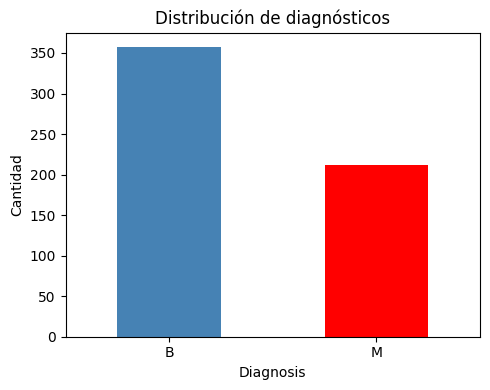

In [29]:
# vamos a ver la distribución de clases
fig, ax = plt.subplots(figsize=(5, 4))
df['Diagnosis'].value_counts().plot(kind='bar', color=['steelblue', 'red'], ax=ax)
ax.set_title('Distribución de diagnósticos')
ax.set_ylabel('Cantidad')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

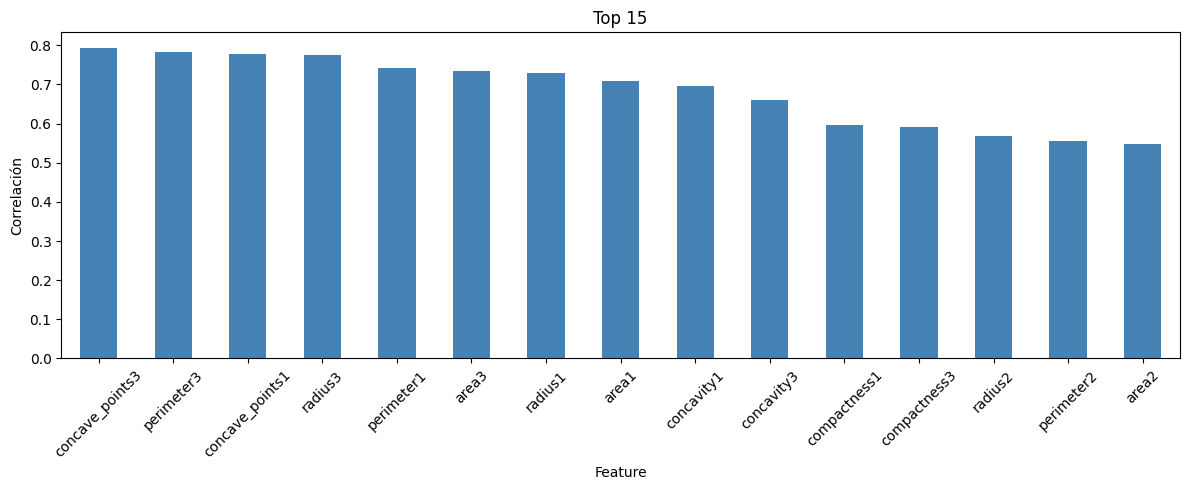

Top 10
concave_points3    0.793566
perimeter3         0.782914
concave_points1    0.776614
radius3            0.776454
perimeter1         0.742636
area3              0.733825
radius1            0.730029
area1              0.708984
concavity1         0.696360
concavity3         0.659610
dtype: float64


In [30]:
# grafica de correlación entre las variables numéricas
# tenemos que convertir Diagnosis a numérico para calcular correlación

df['Diagnosis_num'] = (df['Diagnosis'] == 'M').astype(int)  # M=1, B=0

correlaciones = df.drop(columns=['Diagnosis']).corrwith(df['Diagnosis_num']).abs()
correlaciones = correlaciones.drop('Diagnosis_num').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
correlaciones.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 15')
ax.set_ylabel('Correlación')
ax.set_xlabel('Feature')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("Top 10")
print(correlaciones.head(10))

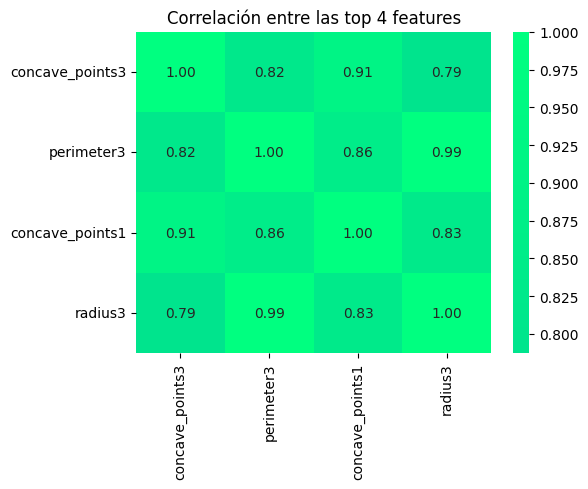

In [31]:
# pero antes tenemos que revisar inter-correlación entre las top 4
top4 = ['concave_points3', 'perimeter3', 'concave_points1', 'radius3']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[top4].corr(), annot=True, fmt='.2f', cmap='winter', center=0, ax=ax)
ax.set_title('Correlación entre las top 4 features')
plt.tight_layout()
plt.show()



### Problema de multicolinealidad 

Como podemos ver en nuestra grafica de correlacion tenemos que nuestro top 4 está muy correlacionado, entonces si nos quedamos solo con esas 4 le estaríamos dando al modelo mucha información pero de lo mismo entonces no tiene caso, entonces vamos a proceder a elegir variamos más diversas

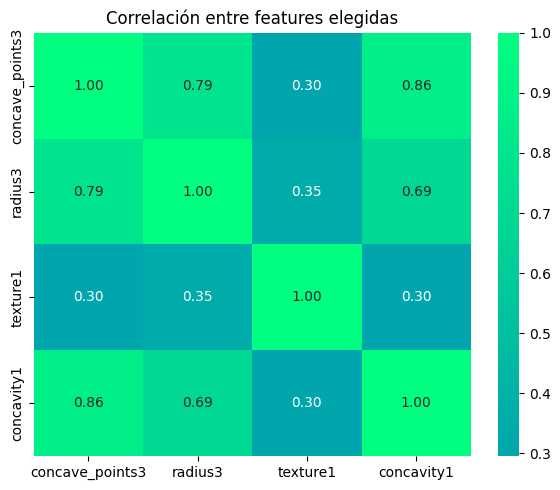

Correlación con Diagnosis:
concave_points3    0.794
radius3            0.776
texture1           0.415
concavity1         0.696
dtype: float64


In [32]:
# combinación más diversa
features_elegidas = ['concave_points3', 'radius3', 'texture1', 'concavity1']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[features_elegidas].corr(), annot=True, fmt='.2f', cmap='winter', center=0, ax=ax)
ax.set_title('Correlación entre features elegidas')
plt.tight_layout()
plt.show()

# Correlación de cada una con el target
print("Correlación con Diagnosis:")
print(df[features_elegidas].corrwith(df['Diagnosis_num']).abs().round(3))

C:\Users\oweno\AppData\Local\Temp\ipykernel_20280\2180974379.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df, palette={'B': 'steelblue', 'M': 'red'}, ax=axes[i])
C:\Users\oweno\AppData\Local\Temp\ipykernel_20280\2180974379.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df, palette={'B': 'steelblue', 'M': 'red'}, ax=axes[i])
C:\Users\oweno\AppData\Local\Temp\ipykernel_20280\2180974379.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=feature, data=df,

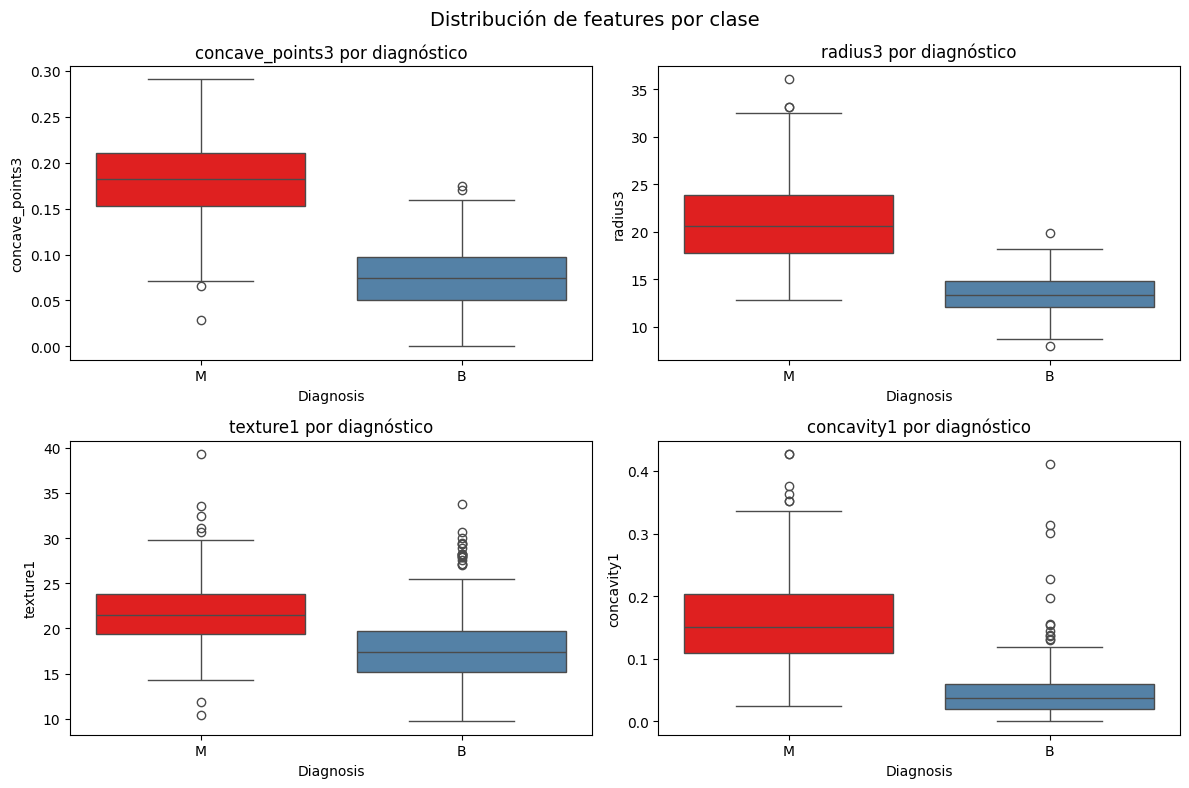

In [33]:
# ahora vamos con una grafica de boxplot para cada una de las features elegidas, separando por clase (B y M)

FEATURES = ['concave_points3', 'radius3', 'texture1', 'concavity1']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(FEATURES):
    sns.boxplot(x='Diagnosis', y=feature, data=df, palette={'B': 'steelblue', 'M': 'red'}, ax=axes[i])
    axes[i].set_title(f'{feature} por diagnóstico')

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

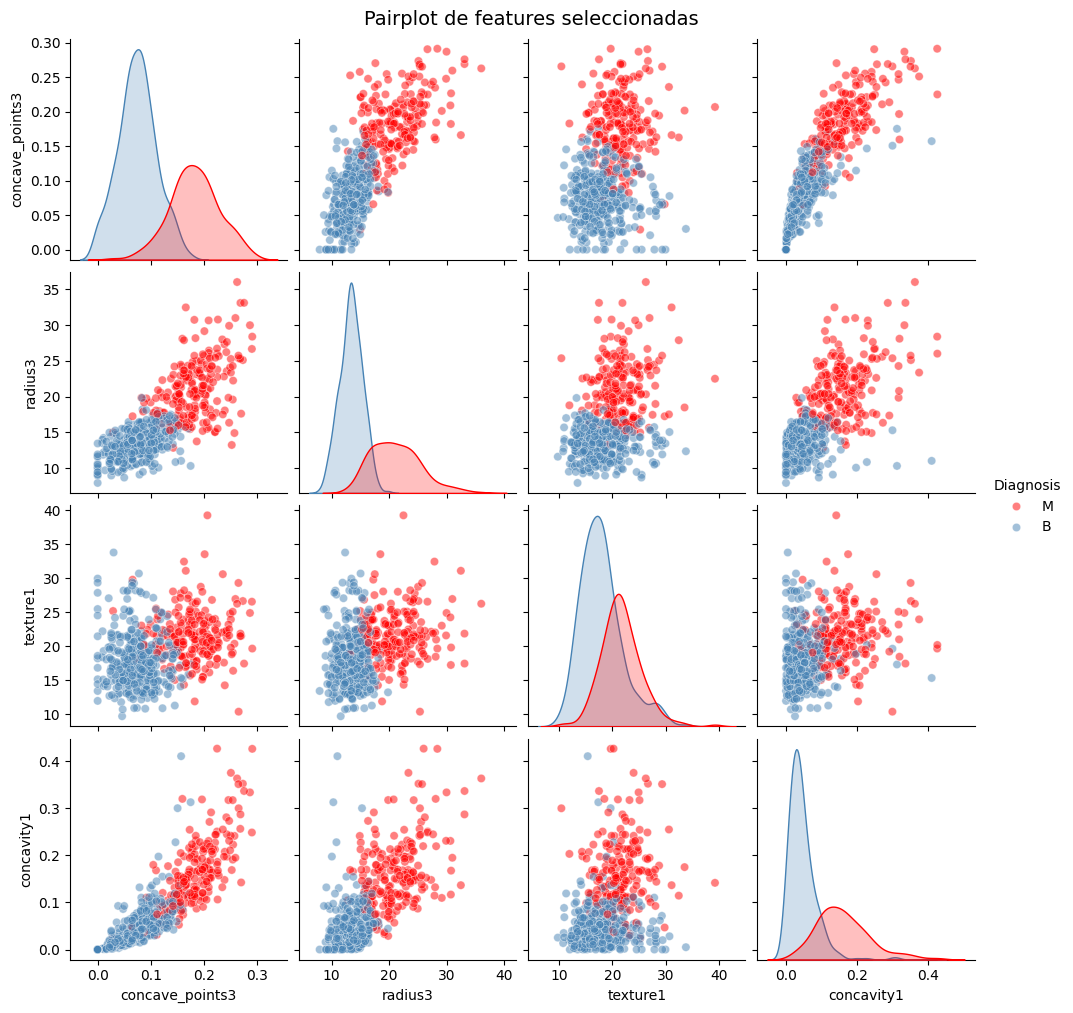

In [34]:
# Gráfica 4: Pairplot
sns.pairplot(df[FEATURES + ['Diagnosis']], hue='Diagnosis', 
             palette={'M': 'red', 'B': 'steelblue'},
             plot_kws={'alpha': 0.5}, diag_kind='kde')
plt.suptitle('Pairplot de features seleccionadas', y=1.01, fontsize=14)
plt.show()

Podemos ver que tenemos diferencia clara entre clases, lo que nos hace pensar que si elegimos bien nuestras variables 

## Conclusiones del EDA

El dataset tiene 357 casos benignos y 212 malignos está moderadamente balanceado.

De las 30 variables disponibles se eligieron 4 con  alta correlación con el diagnóstico pero baja redundancia entre sí:
concave_points3 (0.794), radius3 (0.776), concavity1 (0.696), texture1 (0.415)

Las 4 features muestran diferencias claras entre clases:
- Los tumores **malignos** tienen valores más altos en concave_points3, 
  radius3 y concavity1, lo que indica células más grandes e irregulares.

- texture1 discrimina menos pero aporta información independiente, tiene baja inter-correlación con las demás.

Confirma la separación visual entre clases, especialmente en los ejes de concave_points3 y concavity1. Las distribuciones KDE 
en la diagonal muestran picos bien separados para M y B en casi todas 
las variables. texture1 es la que más traslape tiene entre clases.

Entonces podemos concluir que las features seleccionadas tienen poder discriminativo suficiente para construir un clasificador bayesiano efectivo.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### 3. Modelamiento Bayesiano (20 puntos)

Con base en el punto anterior, escribe claramente tu modelo utilizando el lenguaje probabilístico que vimos en clase. Ten en mente que la modelación de un problema de regresión (variable objetivo continua) y la modelación de un problema de clasificación (variable objetivo binaria), son fundamentalmente diferentes.

El problema es de clasificación binaria M=Maligno, B=Benigno, por lo que 
se utiliza un modelo de regresión logística Bayesiana.

La variable objetivo $y_i \in \{0, 1\}$ (0=Benigno, 1=Maligno) se modela como:

$$y_i \sim \text{Bernoulli}(p_i)$$

$$\text{logit}(p_i) = \alpha + \beta_1 \cdot cp3_i + \beta_2 \cdot r3_i + \beta_3 \cdot tex_i + \beta_4 \cdot con_i$$

Donde:
- $cp3_i$ = concave_points3
- $r3_i$ = radius3
- $tex_i$ = texture1 
- $con_i$ = concavity1

todo estandarizado

### La distribucion de previas es esta:

$$\alpha \sim \text{Normal}(0, 1)$$
$$\beta_1, \beta_2, \beta_3, \beta_4 \sim \text{Normal}(0, 1)$$

#### porque?

- Las previas Normal(0, 1) en el espacio logit son moderadamente informativas: no asumen de antemano si el tumor es maligno o benigno, pero evitan valores extremos. 
- Al estandarizar todas las features, los coeficientes $\beta$ son directamente comparables entre sí.
- Son las mismas previas que utilizamos en clase para regresión logística.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### 4. Validación/reselección de previas (10 puntos)

Usando simulación predictiva previa, asegúrese de que las previas elegidas tengan sentido respecto al problema. De no tenerlo, ajúste su modelo para que lo tenga.

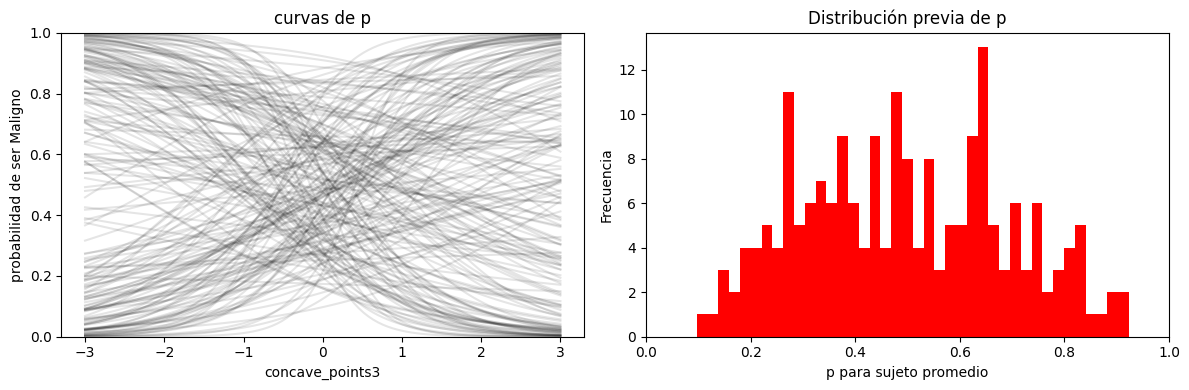

Media de p prior: 0.496


In [35]:
from scipy.special import expit as logistic
import numpy as np

n_samples = 200
# Samplear de las previas con scipy
alpha_s = np.random.normal(0, 1, n_samples)
b1_s    = np.random.normal(0, 1, n_samples)
b2_s    = np.random.normal(0, 1, n_samples)
b3_s    = np.random.normal(0, 1, n_samples)
b4_s    = np.random.normal(0, 1, n_samples)

# Para un rango de valores estandarizados de concave_points3
z_range = np.linspace(-3, 3, 100)

# Calcular p para cada muestra de previas
p_samples = logistic(
    alpha_s[:, None] + b1_s[:, None] * z_range
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Curvas de probabilidad
axes[0].plot(z_range, p_samples.T, 'k', alpha=0.1)
axes[0].set_xlabel('concave_points3')
axes[0].set_ylabel('probabilidad de ser Maligno')
axes[0].set_title('curvas de p')
axes[0].set_ylim(0, 1)

# Distribución de p para un sujeto promedio (z=0)
p_promedio = logistic(alpha_s)
axes[1].hist(p_promedio, bins=40, color='red')
axes[1].set_xlabel('p para sujeto promedio')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución previa de p')
axes[1].set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f'Media de p prior: {p_promedio.mean():.3f}')

La simulación predictiva previa muestra que las previas Normal(0, 1) son buenas porque:
- Las previas generan curvas con toda clase de pendientes, positivas y negativas, cubriendo todo el rango de probabilidades entre 0 y 1. Osea que el modelo no asume de antemano si el tumor es maligno o benigno.
- La probabilidad previa para un sujeto con características promedio es aproximadamente uniforme entre 0 y 1, con media de .510 a .540.
- Por ende nuestras previas son buenas


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### 5. Entrenamiento del modelo (10 puntos)

Dividir los datos en datos de entrenamiento, y datos de prueba.

Programa el modelo en **PyMC** asegurándote de incluir los datos de entrenamiento como variables mutables, para poder reemplazarlos luego por los datos de prueba. Asegúrate de manejar correctamente la(s) variable(s) categóricas, si es que las hay.

In [36]:
from sklearn.model_selection import train_test_split

FEATURES = ['concave_points3', 'radius3', 'texture1', 'concavity1']

# Estandarizar con media y std del dataset completo
X_std = df[FEATURES].copy()
for col in FEATURES:
    X_std[col] = (df[col] - df[col].mean()) / df[col].std()

# Target numérico: M=1, B=0
y = (df['Diagnosis'] == 'M').astype(int).values

# Split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nDistribución en train: M={y_train.sum()}, B={(y_train==0).sum()}')
print(f'Distribución en test:  M={y_test.sum()}, B={(y_test==0).sum()}')

Train: 455 muestras
Test:  114 muestras

Distribución en train: M=170, B=285
Distribución en test:  M=42, B=72


In [37]:
import pymc as pm

with pm.Model() as cancer_model:
    # Datos mutables
    cp3 = pm.Data('cp3', X_train['concave_points3'].values)
    r3  = pm.Data('r3',  X_train['radius3'].values)
    tex = pm.Data('tex', X_train['texture1'].values)
    con = pm.Data('con', X_train['concavity1'].values)

    # Previas
    alpha  = pm.Normal('alpha', mu=0, sigma=1)
    beta1  = pm.Normal('beta1', mu=0, sigma=1)
    beta2  = pm.Normal('beta2', mu=0, sigma=1)
    beta3  = pm.Normal('beta3', mu=0, sigma=1)
    beta4  = pm.Normal('beta4', mu=0, sigma=1)

    # Modelo lineal en espacio logit
    logit_p = pm.Deterministic(
        'logit_p',
        alpha + beta1*cp3 + beta2*r3 + beta3*tex + beta4*con
    )

    # Verosimilitud
    obs = pm.Bernoulli('obs', logit_p=logit_p, observed=y_train)

    # Muestreo MCMC
    idata = pm.sample(random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta3, beta4]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 30 seconds.


------------------------------------------------------------------------------------------------------------------------------------------------------

### 6. Interpretación de distribuciones posteriores (15 puntos)

Con el modelo entrenado, visualiza las distribuciones posteriores y haz una interpretación coherente con la naturaleza del problema de cada una de ellas. Escribe claramente tus **CONCLUSIONES**.

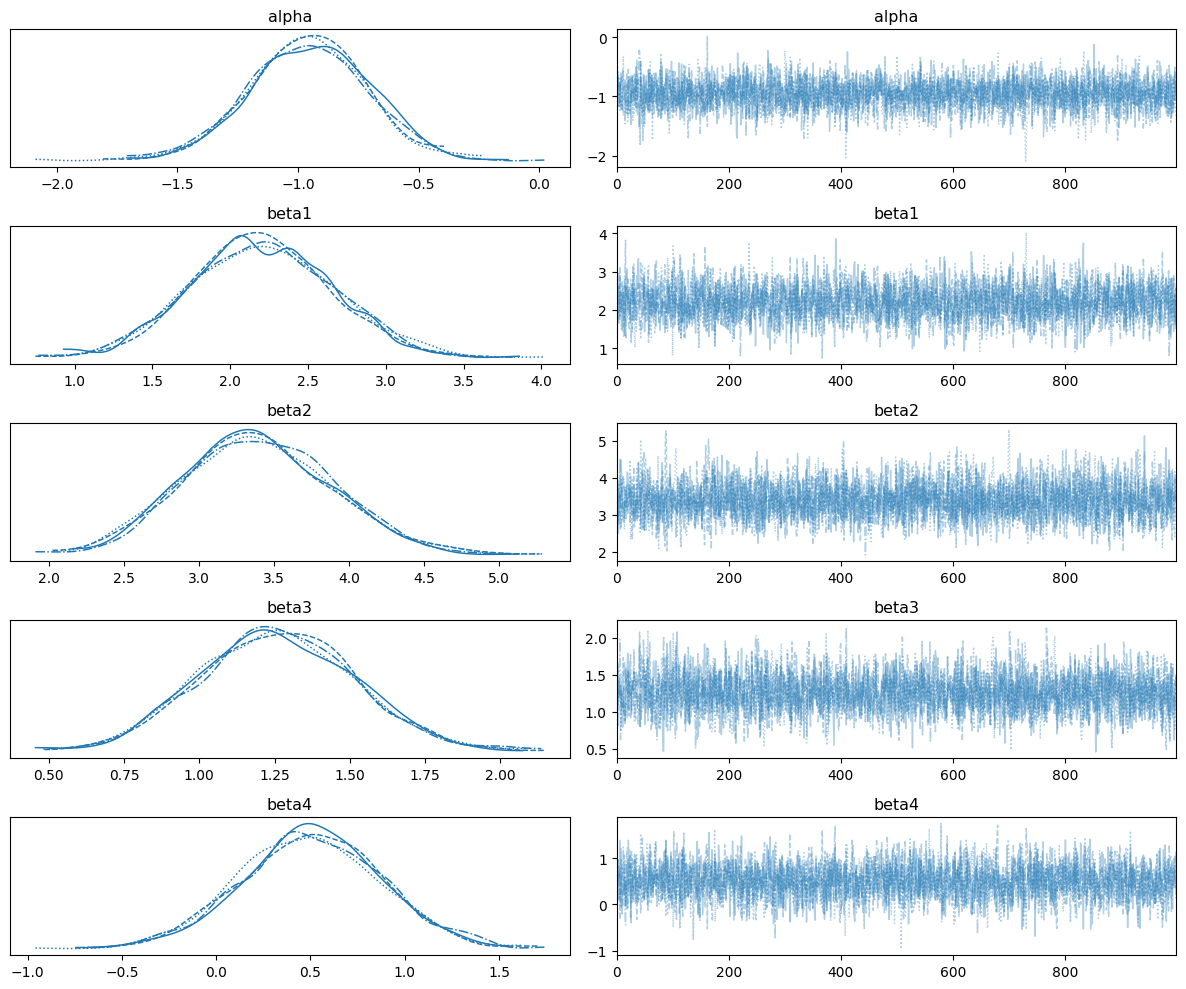

In [38]:
import arviz as az

# Trace plot para ver la convergencia de las cadenas
az.plot_trace(idata, var_names=['alpha', 'beta1', 'beta2', 'beta3', 'beta4'])
plt.tight_layout()
plt.show()

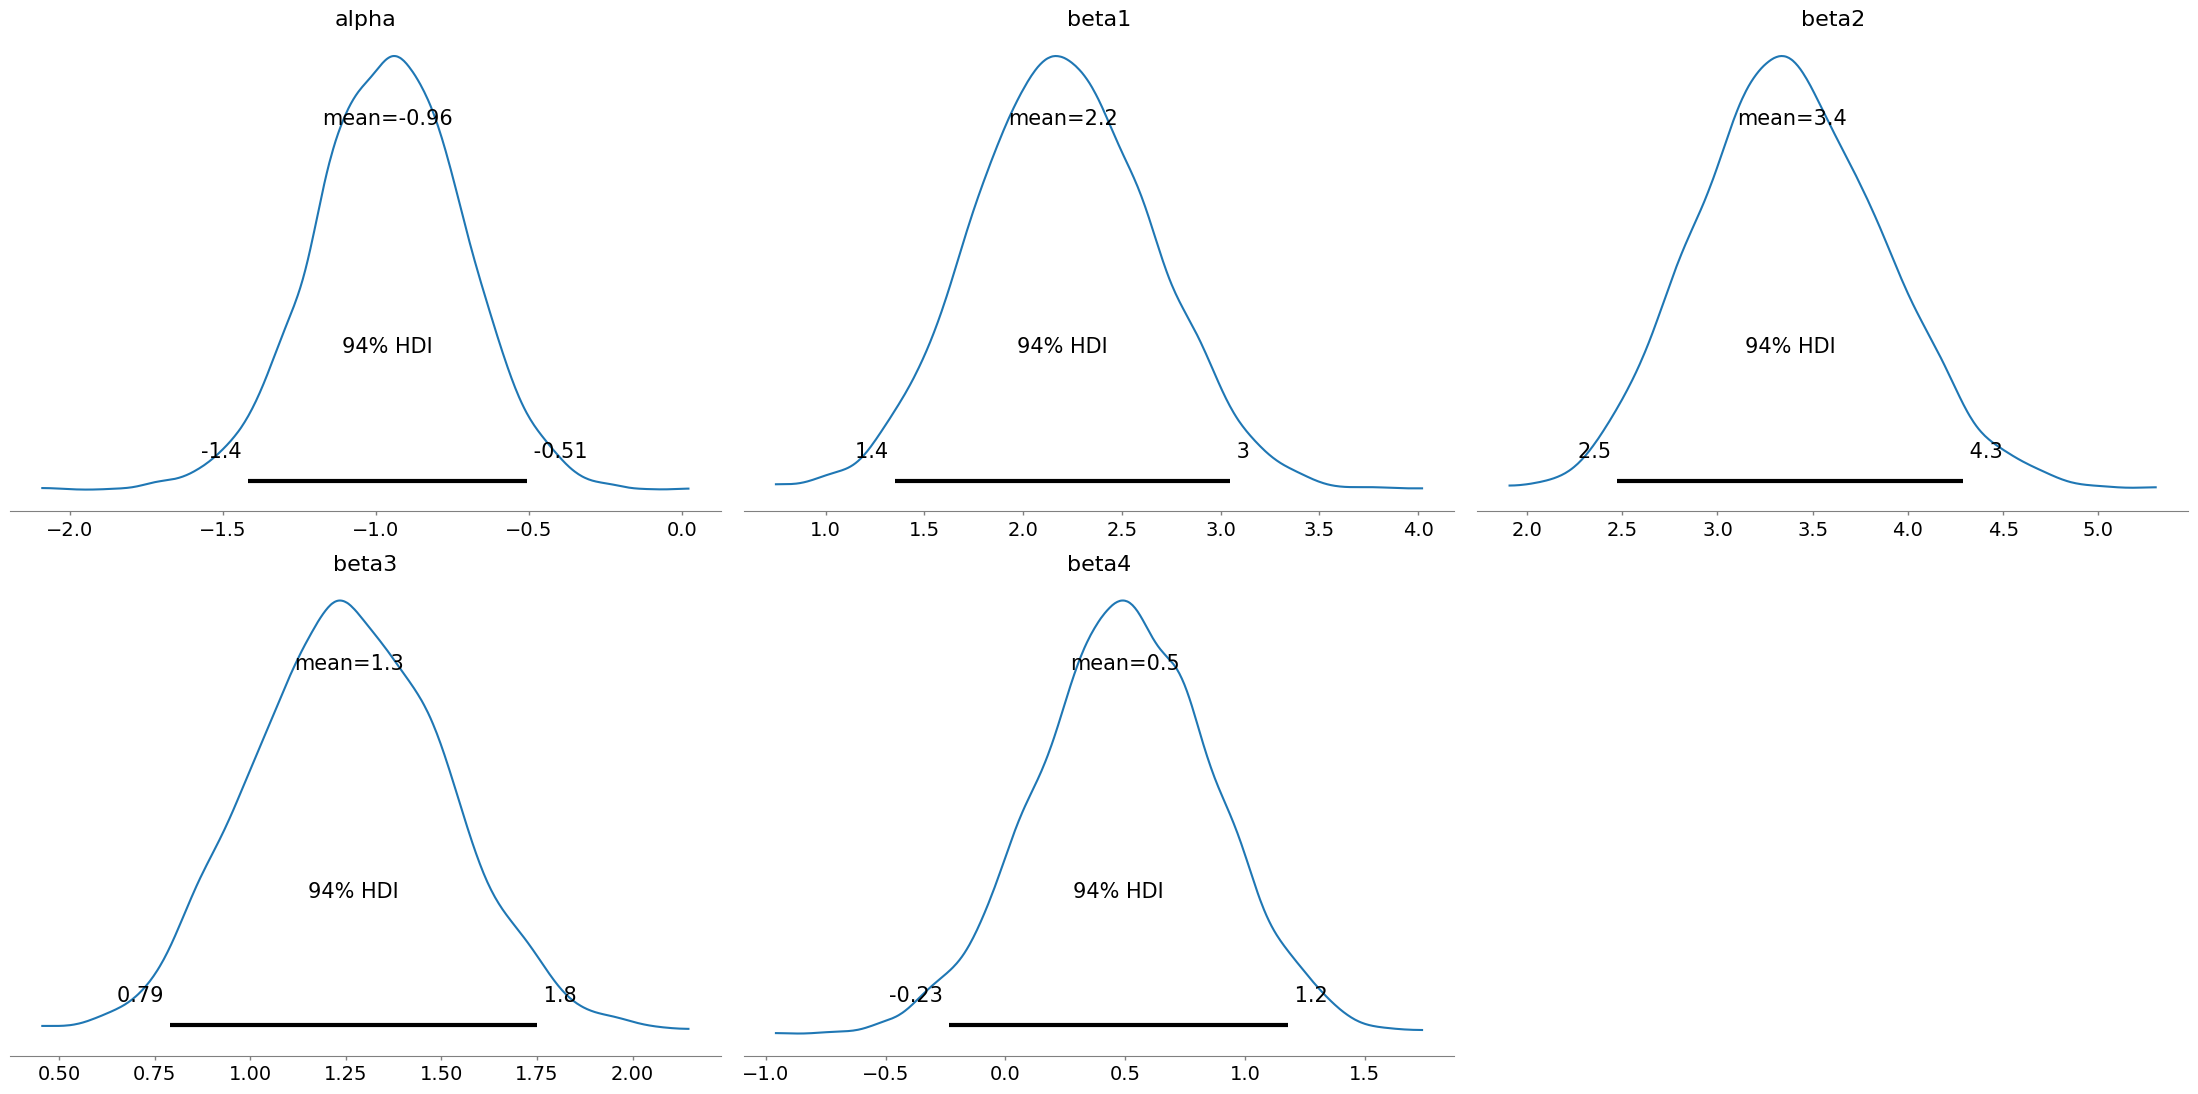

In [39]:
# Distribuciones posteriores
az.plot_posterior(idata, var_names=['alpha', 'beta1', 'beta2', 'beta3', 'beta4'])
plt.tight_layout()
plt.show()

In [40]:
# Resumen numérico
az.summary(idata, var_names=['alpha', 'beta1', 'beta2', 'beta3', 'beta4'], hdi_prob=0.94)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.961,0.244,-1.418,-0.507,0.004,0.004,3615.0,3212.0,1.0
beta1,2.203,0.454,1.352,3.045,0.008,0.006,3192.0,3276.0,1.0
beta2,3.391,0.492,2.474,4.289,0.008,0.008,3721.0,2995.0,1.0
beta3,1.258,0.259,0.790,1.750,0.004,0.004,3428.0,3097.0,1.0
beta4,0.501,0.371,-0.233,1.178,0.006,0.005,3432.0,3168.0,1.0


### Sobre las posteriores que sacamos  

- El trace plot muestra buena convergencia, las 4 cadenas mezclan bien y sus distribuciones se superponen.

alpha -> -0.96 y HDI 94%: [-1.4, -0.51]
El intercepto es negativo y su HDI no incluye el cero. Para un caso promedio, la probabilidad de ser maligno es logistic(-0.96) ≈ 0.28, por lo que podemos decir que el modelo asigna mayor probabilidad a ser benigno por por defecto debido por el desbalance que vimos en el dataset. 

beta1 que tiene que ver con la variable que elegimos de concave_points3 -> 2.2 y HDI 94%: [1.4, 3.0]
Que esta variable haya sido positiva y elejada del cero quiere decir que a mayor número de puntos cóncavos, mayor probabilidad de ser maligno. Tiene mucha relación con que vimos que esta variable tenía la mayor correlación con el diagnóstico.

beta2 que tiene que ver con la variable de radius3 -> 3.4 y HDI 94%: [2.5, 4.3]
Igual que la anterior positiva y alejada del cero, tumores con mayor radio tienen mayor probabilidad a ser malignos ya que las células malignas tienden a ser más grandes. 

beta3 que es texture1 -> 1.3 y HDI 94%: [0.79, 1.8]
Aunque en el EDA era la variable con menor correlación con el diagnóstico (0.415) con el modelo podemos confirmar que sí aporta información, ya que podemos concluir que con mayor textura se asocia con mayor probabilidad de malignidad.  

beta4 que es concavity -> 0.5 y HDI 94%: [-0.23, 1.2]
Esta es la variable que menos aporta al modelo esto puede decir porque puede que su información ya esté siendo capturada por la variable de concave_points3, esto podemos saberlo porque su correlación con esa variable es del 0.86 



---------------------------------------------------------------------------------------------------------------------------------

### 7. Evaluación del modelo (15 puntos)

Evalúa el modelo entrenado, usando las métricas vistas en clase dependiendo de la naturaleza del problema que hayas elegido.

Asegúrate de **CONCLUIR** respecto de tus resultados obtenidos.

In [41]:
with cancer_model:
    pm.set_data({
        'cp3': X_test['concave_points3'].values,
        'r3':  X_test['radius3'].values,
        'tex': X_test['texture1'].values,
        'con': X_test['concavity1'].values,
    })
    ppc = pm.sample_posterior_predictive(
        idata, 
        var_names=['logit_p'],
        random_seed=42
    )

# Convertir logit_p a probabilidades

logit_samples = ppc.posterior_predictive['logit_p'].values  # shape: (chains, draws, obs)
y_scores = logistic(logit_samples).mean(axis=(0, 1))  # promedio sobre chains y draws

print('Shape y_scores:', y_scores.shape)
print('Primeros 10 scores:', y_scores[:10].round(3))

Sampling: []


Output()

Shape y_scores: (114,)
Primeros 10 scores: [0.001 1.    0.237 0.656 0.479 0.012 0.93  0.017 0.002 0.008]


In [42]:
from sklearn.metrics import precision_recall_curve, f1_score

# Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_true=y_test, y_score=y_scores)

# F1 para cada umbral
f1_scores = pd.Series(
    {t: f1_score(y_true=y_test, y_pred=y_scores > t) for t in thresholds}
)
best_threshold = f1_scores.idxmax()
best_f1 = f1_scores.max()

# Accuracy con el mejor umbral
y_pred = (y_scores > best_threshold).astype(int)
accuracy = (y_test == y_pred).mean()

print(f'Mejor umbral: {best_threshold:.3f}')
print(f'Mejor F1:     {best_f1:.3f}')
print(f'Accuracy:     {accuracy:.3f}')

Mejor umbral: 0.237
Mejor F1:     0.966
Accuracy:     0.974


### Conclusiones

Se evaluó el modelo sobre el conjunto de prueba que fueron 114 observaciones, estos son los resultados:

- Accuracy: 0.974 -> el modelo clasifica correctamente el 97.4% de los casos
- F1 Score: 0.966 -> esto quiere decir que el modelo acierta muy bien y lo hace de forma equilibrada tanto para B como para M
- Accuracy: 0.237 -> el umbral es relativamente bajo, lo que para el contexto del cancer de mama es bueno porque es mejor investigar un caso benigno de más que dejar pasar un tumor maligno sin detectar. 

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

<script>
  $(document).ready(function(){
    $('div.prompt').hide();
    $('div.back-to-top').hide();
    $('nav#menubar').hide();
    $('.breadcrumb').hide();
    $('.hidden-print').hide();
  });
</script>

<footer id="attribution" style="float:right; color:#808080; background:#fff;">
Created with Jupyter by Esteban Jiménez Rodríguez.
</footer>